In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
! pip install tensorflow

--- Training LSTM Model ---
Epoch 1/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.0042 - val_loss: 0.0014
Epoch 2/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 3/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0011 - val_loss: 0.0010
Epoch 4/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 9.2377e-04 - val_loss: 8.1992e-04
Epoch 5/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 7.2725e-04 - val_loss: 6.6450e-04
Epoch 6/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 5.3885e-04 - val_loss: 5.4518e-04
Epoch 7/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 4.4531e-04 - val_loss: 3.7691e-04
Epoch 8/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 3.2121e-04 - val_loss: 2.9905e-04
Epoch 9/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 2.5353e-04 - val_loss: 2.5542e-04
Epoch 10/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 2.2208e-04 - val_loss: 1.9787e-04
Epoch 11/30
1687/1687 ━━━━━━━━━━━━━

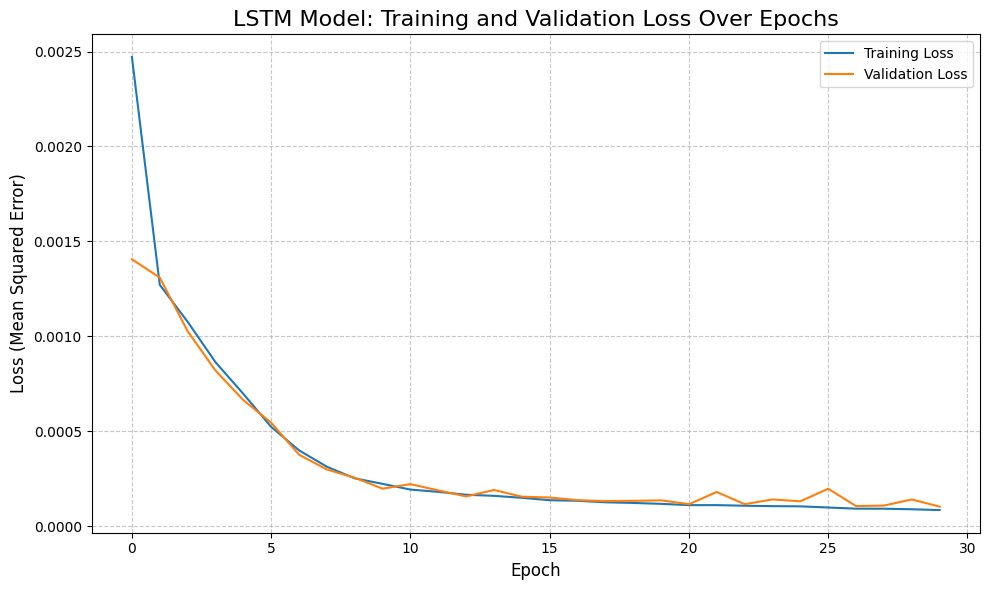

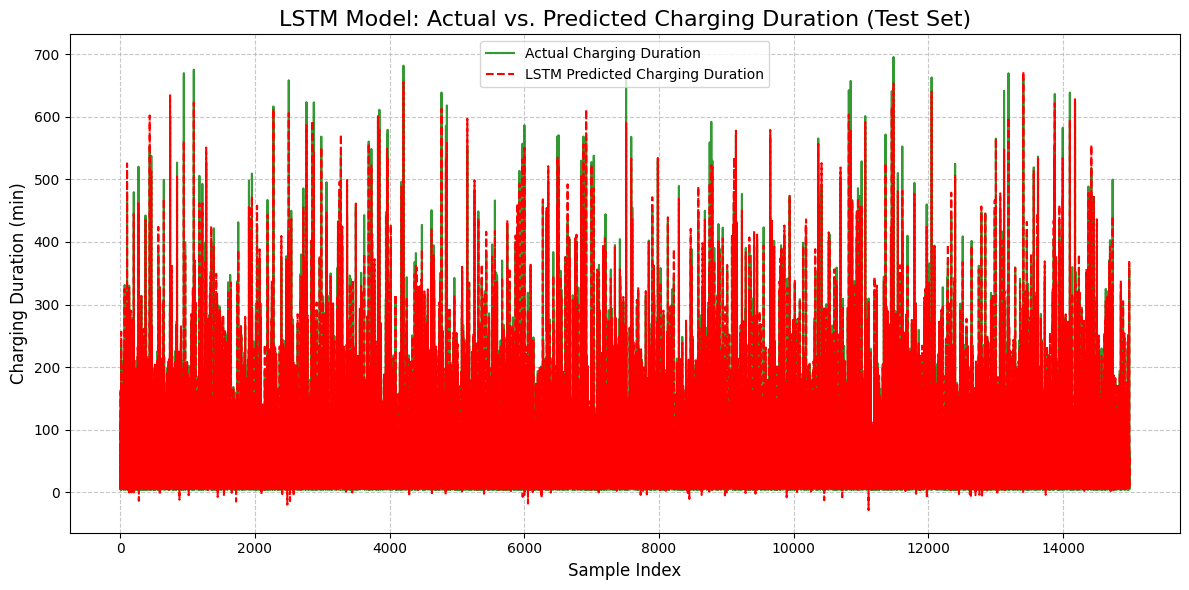

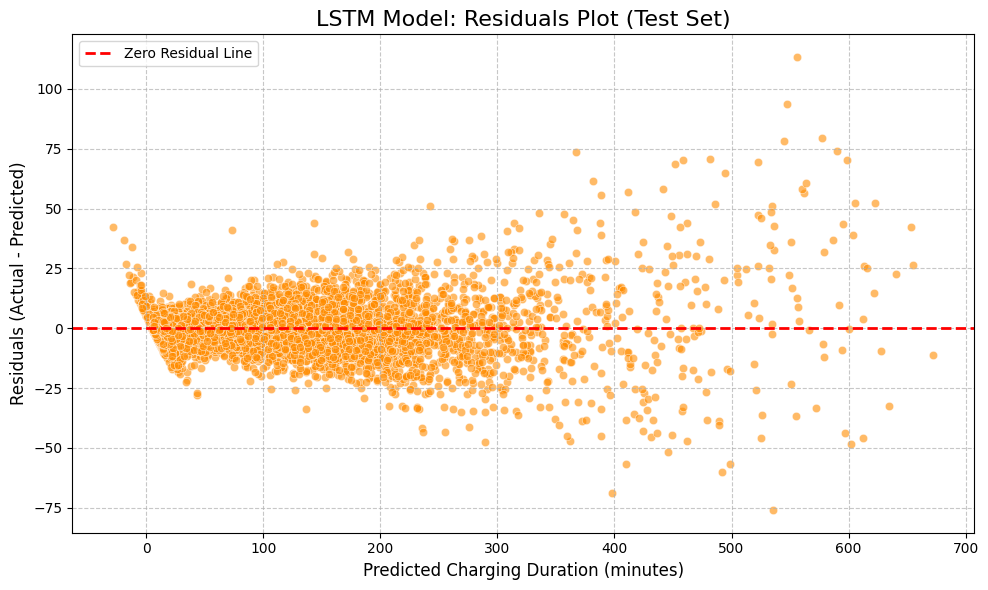


LSTM model evaluation complete. Metrics printed and three plots generated.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.losses import MeanSquaredError
import warnings

# Suppress UserWarning about input_shape and HDF5 saving for cleaner output
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


# --- 1. Load the Dataset ---
# Ensure X_train.csv, X_test.csv, y_train.csv, y_test.csv are accessible.
try:
    X_train = pd.read_csv(r"../data/X_train.csv")
    X_test = pd.read_csv(r"../data/X_test.csv")
    y_train = pd.read_csv(r"../data/y_train.csv")
    y_test = pd.read_csv(r"../data/y_test.csv")
except FileNotFoundError:
    print("Error: One or more data files (X_train.csv, X_test.csv, y_train.csv, y_test.csv) not found.")
    print("Please ensure your preprocessed and split data files are in the correct directory.")
    exit()

# --- 2. Scale features and target ---
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

# --- 3. Reshape data for LSTM (samples, timesteps, features) ---
# Here, timesteps=1, meaning each sample is treated as a sequence of length 1.
# For true sequence modeling over multiple past observations, timesteps would be > 1.
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# --- 4. Build LSTM model ---
model = Sequential()
# LSTM layer with 64 units, input shape matching our reshaped data
model.add(LSTM(64, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]), return_sequences=False))
model.add(Dense(1)) # Output layer for regression (single continuous value)
model.compile(optimizer='adam', loss=MeanSquaredError()) # Using MeanSquaredError object for clarity

# --- 5. Train the model ---
print("--- Training LSTM Model ---")
# validation_split reserves a portion of training data for validation during training
history = model.fit(X_train_lstm, y_train_scaled, epochs=30, batch_size=32, validation_split=0.1, verbose=1)
print("LSTM model training complete.")

# --- 6. Make Predictions for Training and Test Sets ---
# Predictions on training data (in-sample predictions)
y_train_pred_scaled_lstm = model.predict(X_train_lstm)
y_train_pred_lstm = scaler_y.inverse_transform(y_train_pred_scaled_lstm)
y_train_inv = scaler_y.inverse_transform(y_train_scaled) # Original scale of training target

# Predictions on test data (out-of-sample forecasts)
y_test_pred_scaled_lstm = model.predict(X_test_lstm)
y_test_pred_lstm = scaler_y.inverse_transform(y_test_pred_scaled_lstm)
y_test_inv = scaler_y.inverse_transform(y_test_scaled) # Original scale of test target

# --- 7. Evaluate the Model for Training and Test Sets ---
print("\n--- LSTM Model Performance ---")

# Evaluate Training Set
train_mae = mean_absolute_error(y_train_inv, y_train_pred_lstm)
train_rmse = np.sqrt(mean_squared_error(y_train_inv, y_train_pred_lstm))
train_r2 = r2_score(y_train_inv, y_train_pred_lstm)
print("Model performance for Training set")
print(f"- Root Mean Squared Error (RMSE): {train_rmse:.4f}")
print(f"- Mean Absolute Error (MAE): {train_mae:.4f}")
print(f"- R2 Score: {train_r2:.4f}")
print('----------------------------------')

# Evaluate Test Set
test_mae = mean_absolute_error(y_test_inv, y_test_pred_lstm)
test_rmse = np.sqrt(mean_squared_error(y_test_inv, y_test_pred_lstm))
test_r2 = r2_score(y_test_inv, y_test_pred_lstm)
print("Model performance for Test set")
print(f"- Root Mean Squared Error (RMSE): {test_rmse:.4f}")
print(f"- Mean Absolute Error (MAE): {test_mae:.4f}")
print(f"- R2 Score: {test_r2:.4f}")
print('='*35)


# --- 8. Plot 1: Training and Validation Loss ---
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model: Training and Validation Loss Over Epochs', fontsize=16)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (Mean Squared Error)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- 9. Plot 2: Actual vs. Predicted Charging Duration (Test Set) ---
plt.figure(figsize=(12, 6))
# Plot actual test data
plt.plot(y_test_inv, label='Actual Charging Duration', color='green', alpha=0.8)
# Plot LSTM predictions
plt.plot(y_test_pred_lstm, label='LSTM Predicted Charging Duration', color='red', linestyle='--')
plt.title('LSTM Model: Actual vs. Predicted Charging Duration (Test Set)', fontsize=16)
plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Charging Duration (min)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- 10. Plot 3: Residuals Plot (Test Set) ---
# Residuals = Actual Values - Predicted Values
residuals_lstm = y_test_inv - y_test_pred_lstm

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_pred_lstm.flatten(), y=residuals_lstm.flatten(), alpha=0.6, color='darkorange')
plt.axhline(y=0, color='r', linestyle='--', linewidth=2, label='Zero Residual Line')
plt.title('LSTM Model: Residuals Plot (Test Set)', fontsize=16)
plt.xlabel('Predicted Charging Duration (minutes)', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

print("\nLSTM model evaluation complete. Metrics printed and three plots generated.")


In [4]:
X_train = pd.read_csv(r"../data/X_train.csv")
X_test = pd.read_csv(r"../data/X_test.csv")
y_train = pd.read_csv(r"../data/y_train.csv")
y_test = pd.read_csv(r"../data/y_test.csv")

Epoch 1/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 338s 4ms/step - loss: 0.0041 - val_loss: 0.0015
Epoch 2/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 3/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0012 - val_loss: 0.0011
Epoch 4/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 9.6028e-04 - val_loss: 8.5699e-04
Epoch 5/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 7.4187e-04 - val_loss: 7.9803e-04
Epoch 6/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 5.8209e-04 - val_loss: 5.8016e-04
Epoch 7/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 4.1453e-04 - val_loss: 3.8107e-04
Epoch 8/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 3.2450e-04 - val_loss: 2.9798e-04
Epoch 9/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 2.5579e-04 - val_loss: 2.3619e-04
Epoch 10/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 2.2214e-04 - val_loss: 2.1404e-04
Epoch 11/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - los

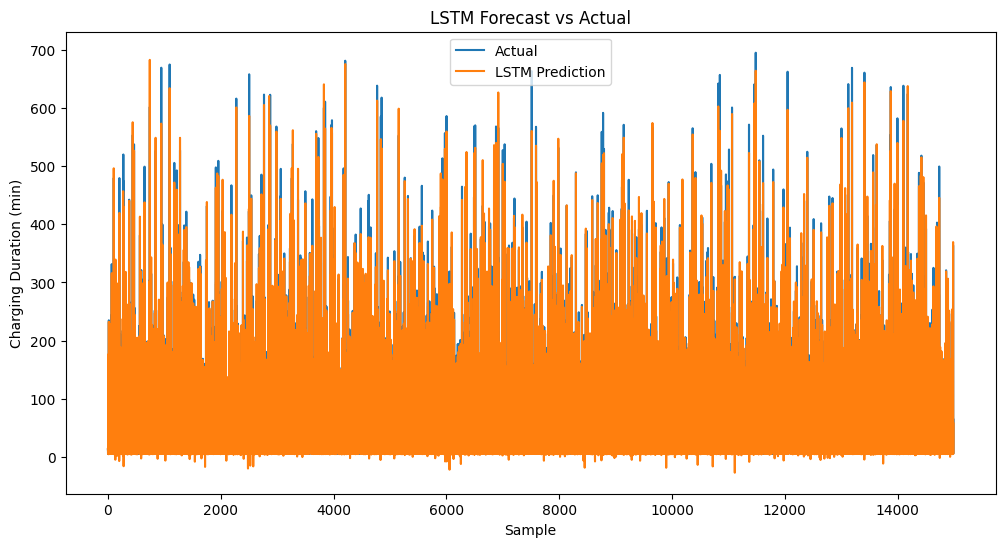

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Load data
X_train = pd.read_csv(r"../data/X_train.csv")
X_test = pd.read_csv(r"../data/X_test.csv")
y_train = pd.read_csv(r"../data/y_train.csv")
y_test = pd.read_csv(r"../data/y_test.csv")

# Scale features
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

# Reshape for LSTM: (samples, timesteps, features)
# Here, timesteps=1 (can be increased for sequence modeling)
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# Build LSTM model
model = Sequential()
model.add(LSTM(64, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]), return_sequences=False))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# Train
history = model.fit(X_train_lstm, y_train_scaled, epochs=30, batch_size=32, validation_split=0.1, verbose=1)

# Predict
y_pred_scaled = model.predict(X_test_lstm)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_inv = scaler_y.inverse_transform(y_test_scaled)

# Evaluate
mse = mean_squared_error(y_test_inv, y_pred)
mae = mean_absolute_error(y_test_inv, y_pred)
r2 = r2_score(y_test_inv, y_pred)

print(f"Test MSE: {mse:.2f}")
print(f"Test MAE: {mae:.2f}")
print(f"Test R2 Score: {r2:.2f}")

# Plot
plt.figure(figsize=(12,6))
plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred, label='LSTM Prediction')
plt.legend()
plt.xlabel('Sample')
plt.ylabel('Charging Duration (min)')
plt.title('LSTM Forecast vs Actual')
plt.show()

In [6]:
import pickle
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.losses import MeanSquaredError

# === Build and Compile the LSTM model ===
model = Sequential()
model.add(LSTM(64, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]), return_sequences=False))
model.add(Dense(1))
model.compile(optimizer='adam', loss=MeanSquaredError())  # ✅ Avoid using 'mse' string

# === Train the model ===
history = model.fit(X_train_lstm, y_train_scaled, epochs=30, batch_size=32, validation_split=0.1, verbose=1)

# === Predict and Evaluate ===
y_pred_scaled = model.predict(X_test_lstm)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_inv = scaler_y.inverse_transform(y_test_scaled)

mse = mean_squared_error(y_test_inv, y_pred)
mae = mean_absolute_error(y_test_inv, y_pred)
r2 = r2_score(y_test_inv, y_pred)

# === Save model and other components ===

# Step 1: Save model to .h5
model_path = "../Saving The Model Results/LSTM_model.h5"
model.save(model_path)

# Step 2: Save scalers and metrics to .pkl
results = {
    "model_path": model_path,
    "scaler_X": scaler_X,
    "scaler_y": scaler_y,
    "mse": mse,
    "mae": mae,
    "r2": r2
}

pkl_path = "../Saving The Model Results/LSTM_model_results.pkl"
with open(pkl_path, "wb") as f:
    pickle.dump(results, f)


Epoch 1/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.0038 - val_loss: 0.0015
Epoch 2/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0013 - val_loss: 0.0014
Epoch 3/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0012 - val_loss: 0.0019
Epoch 4/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0010 - val_loss: 0.0011
Epoch 5/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 8.2283e-04 - val_loss: 7.0105e-04
Epoch 6/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 6.3064e-04 - val_loss: 5.6518e-04
Epoch 7/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 4.9803e-04 - val_loss: 4.4160e-04
Epoch 8/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 3.7633e-04 - val_loss: 6.5526e-04
Epoch 9/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 3.3267e-04 - val_loss: 2.6303e-04
Epoch 10/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 2.5907e-04 - val_loss: 3.0555e-04
Epoch 11/30
1687/1687 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 2.2070

In [7]:
import pickle
from tensorflow.keras.models import load_model

# === Step 1: Load the .pkl file containing scalers and metadata ===
pkl_path = "../Saving The Model Results/LSTM_model_results.pkl"
with open(pkl_path, "rb") as f:
    saved_data = pickle.load(f)

# === Step 2: Load the actual LSTM model using the saved path ===
model = load_model(saved_data["model_path"])

# === Step 3: Load the scalers and evaluation results ===
scaler_X = saved_data["scaler_X"]
scaler_y = saved_data["scaler_y"]
mse = saved_data["mse"]
mae = saved_data["mae"]
r2 = saved_data["r2"]

# === Step 4: Print or reuse the restored components ===
print(f"Restored Model from: {saved_data['model_path']}")
print(f"Restored Test MSE: {mse:.2f}")
print(f"Restored Test MAE: {mae:.2f}")
print(f"Restored Test R²: {r2:.2f}")


Restored Model from: ../Saving The Model Results/LSTM_model.h5
Restored Test MSE: 60.21
Restored Test MAE: 4.37
Restored Test R²: 0.99
